Imports

In [34]:
import os
import numpy as np
import torch
import tqdm
import pathlib
import argparse
import inflect
import pandas as pd
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
import re
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
from transformers import AutoModel, AutoTokenizer, AutoConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForMaskedLM
from sklearn.metrics.pairwise import cosine_similarity 
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package punkt to
[nltk_data]     /home/40455223@eeecs.qub.ac.uk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/40455223@eeecs.qub.ac.uk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Text functions

In [44]:
def remove_punctuation(sentence):
    return re.sub(r'[^\w\s]', '', sentence)

def remove_abbreviations(abbr, sentence):
    sentence = re.sub(r'\([^)]*\)', '', sentence)

    if abbr in sentence:
        sentence = re.sub(abbr, '', sentence)
    return sentence

def remove_stopwords(sentence):
    stop_words = set(stopwords.words('english'))
    return ' '.join([word for word in sentence.split() if word not in stop_words])

def tokenize_sentence(sentence):
    return word_tokenize(sentence)


In [45]:

abbr_1 = "AAA"
sentence_1 = "OBJECTIVE: abdominal aortic aneurysm represents a chronic degenerative condition associated with atherosclerosis."
sentence_2 = "METHODS: The Canadian Institute for Health Information database (a collection of all acute care hospitalizations) was reviewed to identify patients who received nonemergent repair of an AAA  between April 1, 2003 and March 31, 2004."
sentence_3 = "Guidelines from the AAA recommend routine hearing screenings for adults over the age of 50."

sentence_1 = remove_punctuation(sentence_1)
sentence_2 = remove_punctuation(sentence_2)
sentence_3 = remove_punctuation(sentence_3)

sentence_1 = remove_stopwords(sentence_1)
sentence_2 = remove_stopwords(sentence_2)
sentence_3 = remove_stopwords(sentence_3)

print("Sentence 1: ", sentence_1)
print("Sentence 2: ", sentence_2)
print("Sentence 3: ", sentence_3)



Sentence 1:  OBJECTIVE abdominal aortic aneurysm represents chronic degenerative condition associated atherosclerosis
Sentence 2:  METHODS The Canadian Institute Health Information database collection acute care hospitalizations reviewed identify patients received nonemergent repair AAA April 1 2003 March 31 2004
Sentence 3:  Guidelines AAA recommend routine hearing screenings adults age 50


Model functions

In [46]:
# access_token = os.environ.get('HF_TOKEN_LLAMA')

# if access_token is None:
#     raise ValueError("HF_TOKEN_LLAMA is not set")
    
def load_model(name, all_hidden_states=True):
    configuration_class, model_class, tokeniser_class, weights = dev_model_configs[name]
    model, tokeniser = load_model_from_classes(configuration_class, model_class, tokeniser_class, weights, all_hidden_states)
    return model, tokeniser

def load_model_from_classes(configuration_class, model_class, tokeniser_class, weights, all_hidden_states=True):
    config = configuration_class.from_pretrained(weights, output_hidden_states=all_hidden_states)
    model = model_class.from_pretrained(weights, config=config)
        
    tokeniser = tokeniser_class.from_pretrained(weights)
    
    return model, tokeniser



Extracting embeddings

In [52]:
# def get_token_embeddings(model_name, model, tokeniser, input_ids, attention_mask, layers, torch_device, add_arg_dict={}, batch_size = 1, middle_dim=None):
#     print(f'Extracting representations from model for layers {layers}')
#     # Move data to the torch device (cpu or gpu)
#     input_ids = input_ids.to(torch_device)
#     attention_mask = attention_mask.to(torch_device)
#     model.to(torch_device)

#     # Initialize token representations dynamically 
#     tokens_per_layer = [
#         np.zeros((input_ids.shape[0], model.config.hidden_size))
#         for _ in layers
#     ]

#     # Extracting representations during the forward pass
#     with torch.no_grad():
#         for i in tqdm.tqdm(range(0, input_ids.shape[0], batch_size)):
#             outputs = model(
#                 input_ids[i:i+batch_size],
#                 attention_mask=attention_mask[i:i+batch_size],
#                 output_hidden_states=True
#             )
#             hidden_states = outputs.hidden_states[1:]  # Exclude embeddings
#             add_arg_dict["i"] = i

#             # process each layer and get the mean token embedding
#             for layer_idx, layer in enumerate(layers):
#                 token_reps = hidden_states

#                 # Get tokens where tokens aren't special tokens or pad tokens
#                 non_special_token_mask = lambda x: np.array(tokeniser.get_special_tokens_mask(x, already_has_special_tokens=True)) == 0
#                 pad_token_mask = lambda x: np.array(x.cpu() == tokeniser.pad_token_id)
#                 get_tokens_to_keep = lambda x: np.argwhere(non_special_token_mask(x) * (pad_token_mask(x) == False)).reshape(-1)

#                 # Get the mean token embedding
#                 if model_name in ['distilroberta-base', 'xlnet-base-cased', 'xlm-mlm-xnli15-1024']:
#                     layer_reps = token_reps[1][layer].cpu()[:, :, :]
#                 elif layer == model.config.num_hidden_layers:
#                     layer_reps = token_reps[0].cpu()[:, :, :]
#                 elif model_name in ['meta-llama/Llama-3.2-1B', 'microsoft/phi-1', 'openai-community/gpt2', 'meta-llama/Llama-3.2-3B', "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B", "Qwen/Qwen2.5-7B", "mistralai/Mistral-7B-v0.1", "tiiuae/Falcon3-7B-Base", 'google/multiberts-seed_3', 'FacebookAI/roberta-base']:
#                     layer_reps = token_reps[layer].cpu()[:, :, :]
#                 else:
#                     layer_reps = token_reps[2][layer].cpu()[:, :, :]
                
#                 tokens_per_layer[layer_idx][i:i+batch_size, :] = np.vstack([np.mean(reps[get_tokens_to_keep(input_ids[i])].cpu().numpy(), axis=0) for i, reps in enumerate(layer_reps)])
                
#                 # print(tokens_per_layer.shape)

#     return tokens_per_layer


In [81]:
def get_token_embeddings(model_name, model, tokeniser, input_ids, attention_mask, layers, torch_device, add_arg_dict={}, batch_size = 1, middle_dim=None):
    print(f'Extracting representations from model for layers {layers}')
    # Move data to the torch device (cpu or gpu)
    input_ids = input_ids.to(torch_device)
    attention_mask = attention_mask.to(torch_device)
    model.to(torch_device)

    # Initialize token representations dynamically 
    tokens_per_layer = [
        np.zeros((input_ids.shape[0], model.config.hidden_size))
        for _ in layers
    ]

    # Extracting representations during the forward pass
    with torch.no_grad():
        # Using batch_start to avoid shadowing 'i'
        for batch_start in tqdm.tqdm(range(0, input_ids.shape[0], batch_size)):
            outputs = model(
                input_ids[batch_start:batch_start+batch_size],
                attention_mask=attention_mask[batch_start:batch_start+batch_size],
                output_hidden_states=True
            )
            hidden_states = outputs.hidden_states[1:]  # Exclude embeddings
            add_arg_dict["i"] = batch_start

            # Calculate the sequence lengths for the current batch
            batch_attention = attention_mask[batch_start:batch_start+batch_size]
            sequence_lengths = batch_attention.sum(dim=1).cpu().numpy()

            for layer_idx, layer in enumerate(layers):
                token_reps = hidden_states

                # Get the layer representations
                if model_name in ['distilroberta-base', 'xlnet-base-cased', 'xlm-mlm-xnli15-1024']:
                    layer_reps = token_reps[1][layer].cpu()[:, :, :]
                elif layer == model.config.num_hidden_layers:
                    layer_reps = token_reps[0].cpu()[:, :, :]
                elif model_name in ['meta-llama/Llama-3.2-1B', 'microsoft/phi-1', 'openai-community/gpt2', 'meta-llama/Llama-3.2-3B', "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B", "Qwen/Qwen2.5-7B", "mistralai/Mistral-7B-v0.1", "tiiuae/Falcon3-7B-Base", 'google/multiberts-seed_3', 'FacebookAI/roberta-base']:
                    layer_reps = token_reps[layer].cpu()[:, :, :]
                else:
                    layer_reps = token_reps[2][layer].cpu()[:, :, :]
                    
                processed_reps = []
                for local_idx, reps in enumerate(layer_reps):
                  
                    last_token_idx = sequence_lengths[local_idx] - 1
                    
                    # Extract the hidden state vector for just that last token
                    final_token_rep = reps[last_token_idx].numpy()
                    processed_reps.append(final_token_rep)
                
                
                tokens_per_layer[layer_idx][batch_start:batch_start+batch_size, :] = processed_reps
    
    return tokens_per_layer


In [82]:
# torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_device = torch.device("cpu")

model_name = "openai-community/gpt2"
dev_model_configs = {'openai-community/gpt2' : (AutoConfig.from_pretrained("openai-community/gpt2"), AutoModelForCausalLM.from_pretrained("openai-community/gpt2"), AutoTokenizer.from_pretrained("openai-community/gpt2"), 'openai-community/gpt2')}

models = dev_model_configs.keys()

for model_name in tqdm.tqdm(models):
    print('Loading {}'.format(model_name))
    model, tokeniser = load_model(model_name)
    if tokeniser.pad_token is None:
        if tokeniser.eos_token:
            tokeniser.pad_token = tokeniser.eos_token
        else:
            tokeniser.add_special_tokens({'pad_token': '<pad>'})

        #unpack_dict = lambda x: (x['input_ids'], x['attention_mask'])

        
    layers = range(1, model.config.num_hidden_layers + 1)

    layers = [x for x in layers if x in range(1, model.config.num_hidden_layers + 1)]
    
    #sentence 1
    inputs_1 = tokeniser(sentence_1,  max_length = 512, return_tensors="pt", truncation=True, padding=True)
    input_ids_1 = inputs_1["input_ids"]
    attention_mask_1 = inputs_1["attention_mask"]

    sentence_1_embeddings = get_token_embeddings(model_name, model, tokeniser, input_ids_1, attention_mask_1, layers, torch_device, batch_size=1, middle_dim=None)

    #sentence 2
    inputs_2 = tokeniser(sentence_2,  max_length = 512, return_tensors="pt", truncation=True, padding=True)
    input_ids_2 = inputs_2["input_ids"]
    attention_mask_2 = inputs_2["attention_mask"]

    sentence_2_embeddings = get_token_embeddings(model_name, model, tokeniser, input_ids_2, attention_mask_2, layers, torch_device, batch_size=1, middle_dim=None)

    #sentence 3
    inputs_3 = tokeniser(sentence_3,  max_length = 512, return_tensors="pt", truncation=True, padding=True)
    input_ids_3 = inputs_3["input_ids"]
    attention_mask_3 = inputs_3["attention_mask"]

    sentence_3_embeddings = get_token_embeddings(model_name, model, tokeniser, input_ids_3, attention_mask_3, layers, torch_device, batch_size=1, middle_dim=None)

# The embeddings are now a list of numpy arrays, each with shape (num_tokens, embedding_dim)
# The length of the list is the number of layers in the model
    

  0%|          | 0/1 [00:00<?, ?it/s]

Loading openai-community/gpt2


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12262.59it/s]


Extracting representations from model for layers [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


100%|██████████| 1/1 [00:00<00:00,  3.48it/s]


Extracting representations from model for layers [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


100%|██████████| 1/1 [00:00<00:00,  8.83it/s]


Extracting representations from model for layers [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


In [83]:
layers = range(1, model.config.num_hidden_layers + 1)
CosSim_12 = []
CosSim_13 = []
CosSim_23 = []

for layer_idx in range(len(layers)):
    sent_1_layer_embeddings = sentence_1_embeddings[layer_idx]
    sent_2_layer_embeddings = sentence_2_embeddings[layer_idx]
    sent_3_layer_embeddings = sentence_3_embeddings[layer_idx]

    CosSim_12.append(cosine_similarity(sent_1_layer_embeddings, sent_2_layer_embeddings)[0])
    CosSim_13.append(cosine_similarity(sent_1_layer_embeddings, sent_3_layer_embeddings)[0])
    CosSim_23.append(cosine_similarity(sent_2_layer_embeddings, sent_3_layer_embeddings)[0])

    
    

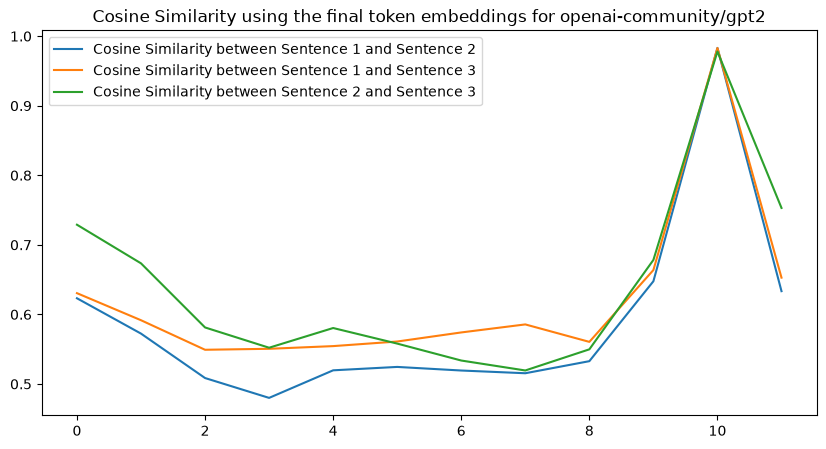

In [85]:
# plot three lines in one plot

plt.figure(figsize=(10, 5))
plt.plot(CosSim_12, label='Cosine Similarity between Sentence 1 and Sentence 2')
plt.plot(CosSim_13, label='Cosine Similarity between Sentence 1 and Sentence 3')
plt.plot(CosSim_23, label='Cosine Similarity between Sentence 2 and Sentence 3')
plt.title(f'Cosine Similarity using the final token embeddings for {model_name}')
plt.legend()
plt.show()
